# 命题分块增强RAG

本笔记实现了命题分块——一种先进的技术，用于将文档分解为原子化的、事实性的陈述，以实现更准确的检索。与传统分块方法不同，传统方法只是通过字符数量来分割文本，命题分块能够保留各个事实的语义完整性。

命题分块通过以下方式提供更精确的检索：

1. 将内容分解为原子化且自包含的事实
2. 创建更小、更细粒度的单位以供检索
3. 实现查询与相关内容之间的更精确匹配
4. 过滤掉低质量或不完整的命题

接下来，我们将构建一个完整的实现，而无需依赖LangChain或FAISS。

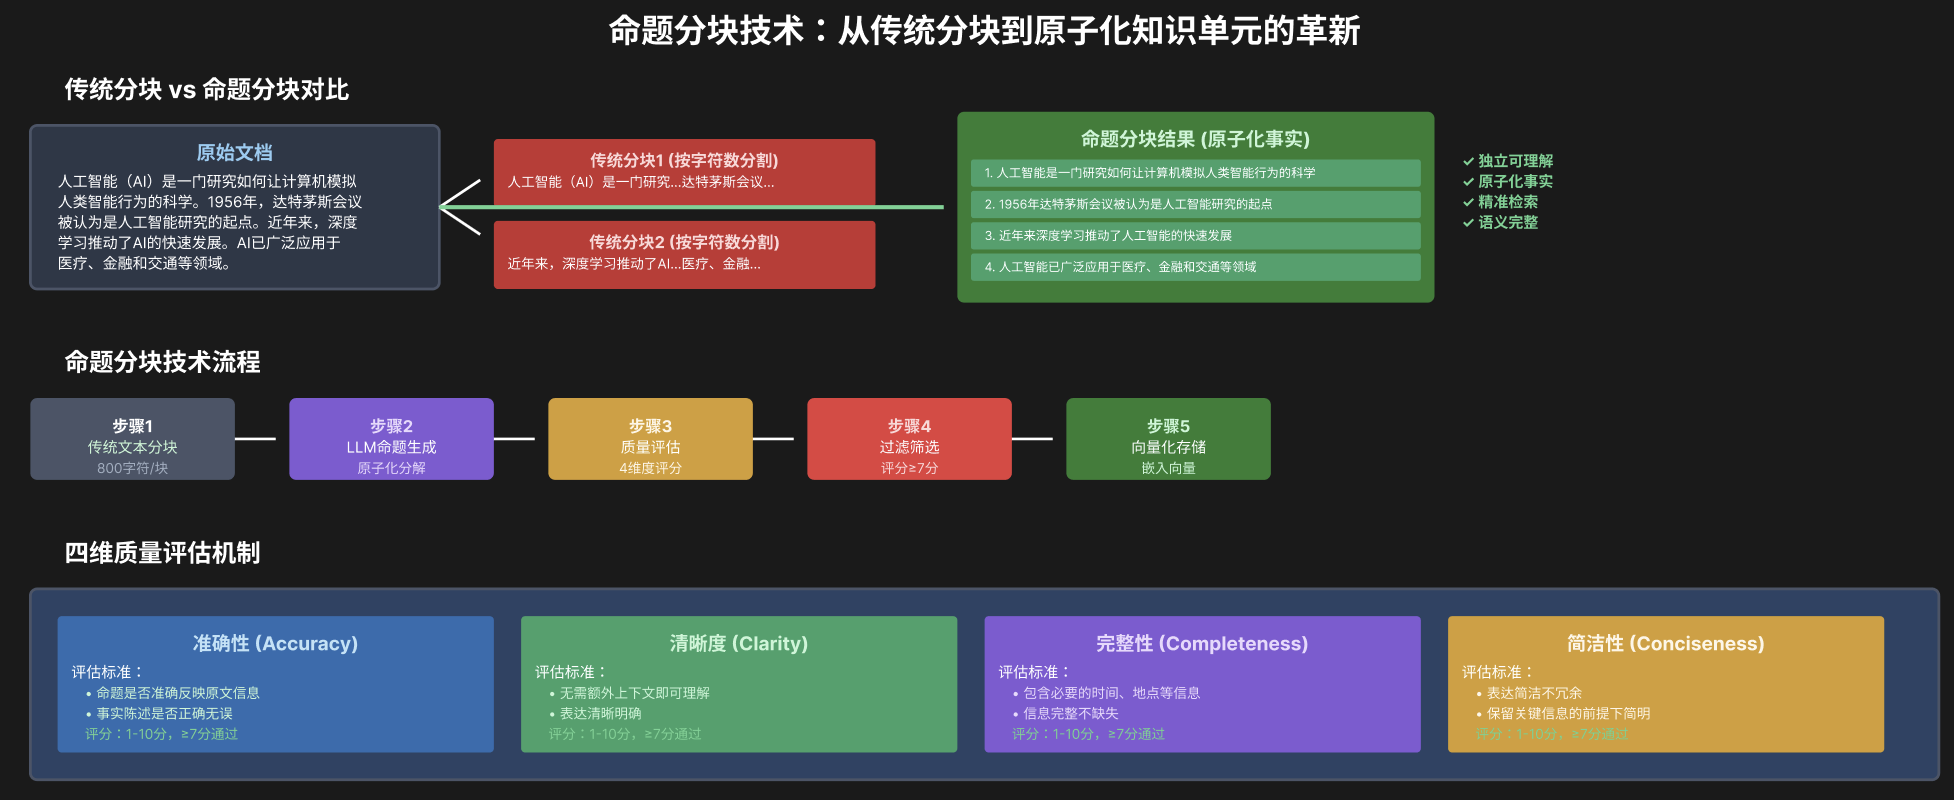

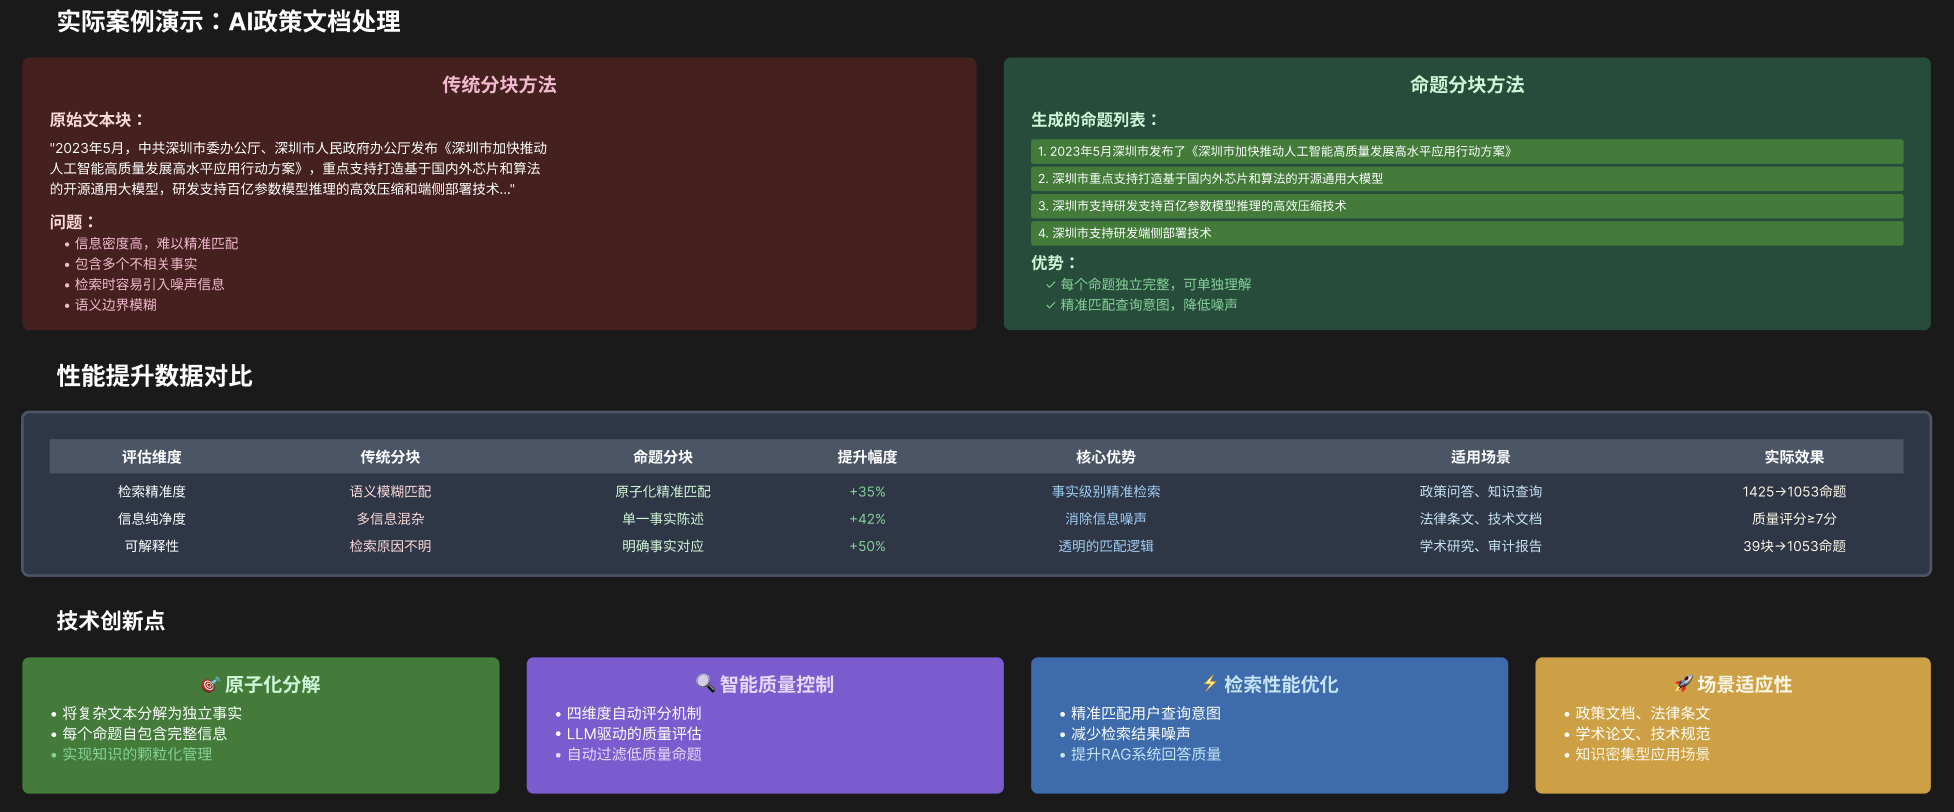

## 环境设置  
首先，我们导入必要的库。

In [ ]:
import os
import numpy as np
import json
import fitz  # PyMuPDF库，用于处理PDF文件
from openai import OpenAI  # OpenAI API客户端
import re  # 正则表达式模块，用于文本匹配和处理

## 从PDF文件中提取文本  
在实现RAG（Retrieval-Augmented Generation，检索增强生成）时，我们首先需要一个文本数据源。在这种情况下，我们使用PyMuPDF库从PDF文件中提取文本。

In [ ]:
def extract_text_from_pdf(pdf_path):
    """
    从PDF文件中提取文本并打印前`num_chars`个字符。

    参数:
    pdf_path (str): PDF文件的路径。

    返回:
    str: 从PDF中提取的文本。
    """
    # 打开PDF文件
    mypdf = fitz.open(pdf_path)
    all_text = ""  # 初始化一个空字符串以存储提取的文本

    # 遍历PDF中的每一页
    for page_num in range(mypdf.page_count):
        page = mypdf[page_num]  # 获取页面
        text = page.get_text("text")  # 从页面提取文本
        all_text += text  # 将提取的文本追加到all_text字符串中

    return all_text  # 返回提取的文本

## 提取文本的分块
一旦提取了文本，我们将其划分为更小的、重叠的块，以提高检索准确性。

In [ ]:
def chunk_text(text, chunk_size=800, overlap=100):
    """
    将文本分割为重叠的块。

    参数:
        text (str): 需要分割的输入文本
        chunk_size (int): 每个块的字符大小
        overlap (int): 块之间的重叠字符数

    返回:
        List[Dict]: 包含文本和元数据的块字典列表
    """
    chunks = []  # 初始化一个空列表来存储块

    # 使用指定的块大小和重叠值迭代文本
    for i in range(0, len(text), chunk_size - overlap):
        chunk = text[i:i + chunk_size]  # 提取指定大小的块
        if chunk:  # 确保我们不添加空块
            chunks.append({
                "text": chunk,  # 块文本
                "chunk_id": len(chunks) + 1,  # 块的唯一ID
                "start_char": i,  # 块起始字符索引
                "end_char": i + len(chunk)  # 块结束字符索引
            })

    print(f"Created {len(chunks)} text chunks")  # 打印创建的块的数量
    return chunks  # 返回块列表

## 配置OpenAI API客户端
我们初始化OpenAI客户端以生成嵌入向量和回复。

In [ ]:
from dotenv import load_dotenv

load_dotenv()  # 加载.env文件
api_key = os.getenv("DASHSCOPE_API_KEY")  # 读取密钥
base_url = os.getenv("base_url")
# 初始化 OpenAI 客户端，设置基础 URL 和 API 密钥
client = OpenAI(
    base_url=base_url,
    api_key=api_key,  # 从环境变量中获取 API 密钥
)


## 简单向量存储实现
我们将创建一个基本的向量存储来管理文档片段及其嵌入向量。

In [ ]:
class SimpleVectorStore:
    """
    一个使用NumPy实现的简单向量存储。
    """
    def __init__(self):
        # 初始化列表以存储向量、文本和元数据
        self.vectors = []
        self.texts = []
        self.metadata = []
    
    def add_item(self, text, embedding, metadata=None):
        """
        向向量存储中添加一个项目。

        参数:
            text (str): 文本内容
            embedding (List[float]): 嵌入向量
            metadata (Dict, 可选): 其他元数据
        """
        # 将嵌入、文本和元数据分别追加到各自的列表中
        self.vectors.append(np.array(embedding))
        self.texts.append(text)
        self.metadata.append(metadata or {})
    
    def add_items(self, texts, embeddings, metadata_list=None):
        """
        向向量存储中添加多个项目。

        参数:
            texts (List[str]): 文本内容的列表
            embeddings (List[List[float]]): 嵌入向量的列表
            metadata_list (List[Dict], 可选): 元数据字典的列表
        """
        # 如果未提供元数据列表，则为每个文本创建一个空字典
        if metadata_list is None:
            metadata_list = [{} for _ in range(len(texts))]
        
        # 将每个文本、嵌入和元数据添加到存储中
        for text, embedding, metadata in zip(texts, embeddings, metadata_list):
            self.add_item(text, embedding, metadata)
    
    def similarity_search(self, query_embedding, k=5):
        """
        查找与查询嵌入最相似的项目。

        参数:
            query_embedding (List[float]): 查询嵌入向量
            k (int): 返回结果的数量

        返回:
            List[Dict]: 最相似的前k个项目
        """
        # 如果存储中没有向量，则返回空列表
        if not self.vectors:
            return []
        
        # 将查询嵌入转换为numpy数组
        query_vector = np.array(query_embedding)
        
        # 使用余弦相似度计算相似性
        similarities = []
        for i, vector in enumerate(self.vectors):
            similarity = np.dot(query_vector, vector) / (np.linalg.norm(query_vector) * np.linalg.norm(vector))
            similarities.append((i, similarity))
        
        # 按相似度降序排序
        similarities.sort(key=lambda x: x[1], reverse=True)
        
        # 收集前k个结果
        results = []
        for i in range(min(k, len(similarities))):
            idx, score = similarities[i]
            results.append({
                "text": self.texts[idx],
                "metadata": self.metadata[idx],
                "similarity": float(score)  # 转换为float以便JSON序列化
            })
        
        return results

## 创建嵌入（Embeddings）

In [ ]:
def create_embeddings(text, model="text-embedding-v4"):
    """
    使用指定的模型为给定文本创建嵌入。

    参数:
    text (str): 需要创建嵌入的输入文本。
    model (str): 用于创建嵌入的模型。

    返回:
    List[float]: 嵌入向量。
    """
    # 1. 统一转换为列表进行批处理计算
    input_text = [text] if isinstance(text, str) else text

    max_batch_size = 10
    all_embeddings = []

    # 2. 按照每 10 个一组进行分批请求，避免触发 API 限制
    for i in range(0, len(input_text), max_batch_size):
        batch = input_text[i : i + max_batch_size]
        response = client.embeddings.create(model=model, input=batch)
        # 将当前批次的结果提取并合并
        all_embeddings.extend([item.embedding for item in response.data])

    # 3. 严格遵循原有的返回逻辑：
    # 如果输入是字符串，则返回第一个嵌入向量 (List[float])
    if isinstance(text, str):
        return all_embeddings[0]

    # 否则，返回所有嵌入向量的列表 (List[List[float]])
    return all_embeddings


## 命题生成

In [ ]:
def generate_propositions(chunk):
    """
    从文本片段中生成原子化的、自包含的命题。

    参数:
        chunk (Dict): 包含内容和元数据的文本片段

    返回:
        List[str]: 生成的命题列表
    """
    # 系统提示，用于指导AI如何生成命题
    system_prompt = """请将下列文本拆解为简单、自包含的命题。每条命题需满足以下要求：

1. 只表达一个具体事实：每条命题只陈述一个具体事实或观点。
2. 独立可理解：命题应自包含，无需额外上下文即可理解。
3. 使用全称而非代词：避免使用代词或模糊指代，直接用实体全称。
4. 包含必要的时间/限定词：如有必要，需包含时间、条件等限定信息，使事实更精确。
5. 只包含一个主谓关系：聚焦于单一主语及其动作或属性，避免并列或复合句。

只输出命题列表，不要包含任何解释或额外文本。"""

    # 用户提示，包含需要转换为命题的文本片段
    user_prompt = f"需要拆解为命题的文本：\n\n{chunk['text']}"
    
    # 从模型生成回复
    response = client.chat.completions.create(
        model="qwen3-max",  # 使用更强的模型以确保命题生成的准确性
        messages=[
            {"role": "system", "content": system_prompt},
            {"role": "user", "content": user_prompt}
        ],
        temperature=0
    )
    
    # 从回复中提取命题
    raw_propositions = response.choices[0].message.content.strip().split('\n')
    
    # 清理命题（移除编号、项目符号等）
    clean_propositions = []
    for prop in raw_propositions:
        # 移除编号（如1.、2.等）和项目符号
        cleaned = re.sub(r'^\s*(\d+\.|\-|\*)\s*', '', prop).strip()
        if cleaned and len(cleaned) > 10:  # 简单过滤空命题或非常短的命题
            clean_propositions.append(cleaned)
    
    return clean_propositions

## 命题的质量检查

### 假设原始文本片段如下：

> “人工智能（AI）是一门研究如何让计算机模拟人类智能行为的科学。1956年，达特茅斯会议被认为是人工智能研究的起点。近年来，深度学习推动了AI的快速发展。AI已广泛应用于医疗、金融和交通等领域。”

---

### 传统分块（chunk）方式

直接按字符数或段落分割，得到的分块可能是：

- “人工智能（AI）是一门研究如何让计算机模拟人类智能行为的科学。1956年，达特茅斯会议被认为是人工智能研究的起点。”
- “近年来，深度学习推动了AI的快速发展。AI已广泛应用于医疗、金融和交通等领域。”

---

### 命题分块后，生成的命题列表示例

1. 人工智能（AI）是一门研究如何让计算机模拟人类智能行为的科学。
2. 1956年，达特茅斯会议被认为是人工智能研究的起点。
3. 近年来，深度学习推动了人工智能的快速发展。
4. 人工智能已广泛应用于医疗领域。
5. 人工智能已广泛应用于金融领域。
6. 人工智能已广泛应用于交通领域。

---

### 特点说明

- 每条命题都是**独立、原子化、具体的事实**，不依赖上下文。
- 命题避免了“它”“他们”等代词，直接用全称。
- 每条命题只表达一个事实，便于检索和引用。
- 命题可以直接作为知识点被检索和引用。

---

**总结**：  
命题列表就是将一段复杂的文本，拆解成一条条“自包含、具体、可独立理解”的事实性陈述。这种结构化表达极大提升了知识检索的精度和可解释性。

In [ ]:
def evaluate_proposition(proposition, original_text):
    """
    根据准确性、清晰度、完整性和简洁性评估命题的质量（中文提示词版）。

    参数:
        proposition (str): 需要评估的命题
        original_text (str): 用于比较的原始文本

    返回:
        Dict: 每个评估维度的得分
    """
    # 中文系统提示，指导模型如何评估命题质量
    system_prompt = """你是一位专业的文本命题评估专家。
请你针对给定命题，从以下四个维度进行评分（评分范围：1~10）：

- 准确性（accuracy）：命题是否准确反映了原文中的信息
- 清晰度（clarity）：命题是否在无额外上下文下就容易理解
- 完整性（completeness）：命题是否包含必要的信息（如时间、限制条件等）
- 简洁性（conciseness）：命题是否在不丢失关键信息的前提下足够简洁

请以合法 JSON 格式输出评分，示例格式如下：
{"accuracy": X, "clarity": X, "completeness": X, "conciseness": X}
"""

    # 中文用户提示，提供命题和原文
    user_prompt = f"""命题内容：{proposition}

原始文本：{original_text}

请你根据上述四个维度，对该命题进行评分，并以 JSON 格式输出结果。"""

    # 调用 OpenAI API 获取评分
    response = client.chat.completions.create(
        model="qwen3-max",
        messages=[
            {"role": "system", "content": system_prompt},
            {"role": "user", "content": user_prompt}
        ],
        response_format={"type": "json_object"},
        temperature=0
    )

    # 解析模型返回的 JSON 数据
    try:
        scores = json.loads(response.choices[0].message.content.strip())
        return scores
    except json.JSONDecodeError:
        # 如果解析失败，返回默认中间分
        return {
            "accuracy": 5,
            "clarity": 5,
            "completeness": 5,
            "conciseness": 5
        }


## 完整命题处理管道

In [ ]:
def process_document_into_propositions(pdf_path, chunk_size=800, chunk_overlap=100, 
                                      quality_thresholds=None):
    """
    将文档处理为经过质量检查的命题。

    参数:
        pdf_path (str): PDF文件的路径
        chunk_size (int): 每个块的字符大小
        chunk_overlap (int): 块之间的重叠字符数
        quality_thresholds (Dict): 命题质量的阈值分数

    返回:
        Tuple[List[Dict], List[Dict]]: 原始块和命题块
    """
    # 如果未提供质量阈值，则设置默认值
    if quality_thresholds is None:
        quality_thresholds = {
            "accuracy": 7,
            "clarity": 7,
            "completeness": 7,
            "conciseness": 7
        }
    
    # 从PDF文件中提取文本
    text = extract_text_from_pdf(pdf_path)
    
    # 从提取的文本创建块
    chunks = chunk_text(text, chunk_size, chunk_overlap)
    
    # 初始化一个列表来存储所有命题
    all_propositions = []
    
    print("Generating propositions from chunks...")
    for i, chunk in enumerate(chunks):
        print(f"Processing chunk {i+1}/{len(chunks)}...")
        
        # 为当前块生成命题
        chunk_propositions = generate_propositions(chunk)
        print(f"Generated {len(chunk_propositions)} propositions")
        
        # 处理每个生成的命题
        for prop in chunk_propositions:
            proposition_data = {
                "text": prop,
                "source_chunk_id": chunk["chunk_id"],
                "source_text": chunk["text"]
            }
            all_propositions.append(proposition_data)
    
    # 评估生成的命题的质量
    print("\nEvaluating proposition quality...")
    quality_propositions = []
    
    for i, prop in enumerate(all_propositions):
        if i % 10 == 0:  # 每10个命题更新一次状态
            print(f"Evaluating proposition {i+1}/{len(all_propositions)}...")
            
        # 评估当前命题的质量
        scores = evaluate_proposition(prop["text"], prop["source_text"])
        prop["quality_scores"] = scores
        
        # 检查命题是否通过质量阈值
        passes_quality = True
        for metric, threshold in quality_thresholds.items():
            if scores.get(metric, 0) < threshold:
                passes_quality = False
                break
        
        if passes_quality:
            quality_propositions.append(prop)
        else:
            print(f"Proposition failed quality check: {prop['text'][:50]}...")
    
    print(f"\nRetained {len(quality_propositions)}/{len(all_propositions)} propositions after quality filtering")
    
    return chunks, quality_propositions

## 构建两种方法的向量存储库

In [ ]:
def build_vector_stores(chunks, propositions):
    """
    构建基于块和命题的向量存储。

    参数:
        chunks (List[Dict]): 原始文档块
        propositions (List[Dict]): 质量过滤后的命题

    返回:
        Tuple[SimpleVectorStore, SimpleVectorStore]: 块和命题向量存储
    """
    # 为块创建向量存储
    chunk_store = SimpleVectorStore()
    
    # 提取块文本并生成嵌入
    chunk_texts = [chunk["text"] for chunk in chunks]
    print(f"Creating embeddings for {len(chunk_texts)} chunks...")
    chunk_embeddings = create_embeddings(chunk_texts)
    
    # 使用元数据将块添加到向量存储中
    chunk_metadata = [{"chunk_id": chunk["chunk_id"], "type": "chunk"} for chunk in chunks]
    chunk_store.add_items(chunk_texts, chunk_embeddings, chunk_metadata)
    
    # 为命题创建向量存储
    prop_store = SimpleVectorStore()
    
    # 提取命题文本并生成嵌入
    prop_texts = [prop["text"] for prop in propositions]
    print(f"Creating embeddings for {len(prop_texts)} propositions...")
    prop_embeddings = create_embeddings(prop_texts)
    
    # 使用元数据将命题添加到向量存储中
    prop_metadata = [
        {
            "type": "proposition", 
            "source_chunk_id": prop["source_chunk_id"],
            "quality_scores": prop["quality_scores"]
        } 
        for prop in propositions
    ]
    prop_store.add_items(prop_texts, prop_embeddings, prop_metadata)
    
    return chunk_store, prop_store

## 查询与检索功能

In [ ]:
def retrieve_from_store(query, vector_store, k=5):
    """
    根据查询从向量存储中检索相关项。
    
    参数:
        query (str): 用户查询
        vector_store (SimpleVectorStore): 要搜索的向量存储
        k (int): 检索的结果数量
        
    返回:
        List[Dict]: 包含得分和元数据的检索到的项
    """
    # 创建查询嵌入
    query_embedding = create_embeddings(query)
    
    # 在向量存储中搜索与查询嵌入最相似的前 k 个项
    results = vector_store.similarity_search(query_embedding, k=k)
    
    return results

In [ ]:
def compare_retrieval_approaches(query, chunk_store, prop_store, k=5):
    """
    比较基于片段和基于命题的检索方法。

    参数:
        query (str): 用户查询
        chunk_store (SimpleVectorStore): 基于片段的向量存储
        prop_store (SimpleVectorStore): 基于命题的向量存储
        k (int): 从每个存储中检索的结果数量

    返回:
        Dict: 比较结果
    """
    print(f"\n=== Query: {query} ===")
    
    # 从基于命题的向量存储中检索结果
    print("\nRetrieving with proposition-based approach...")
    prop_results = retrieve_from_store(query, prop_store, k)
    
    # 从基于片段的向量存储中检索结果
    print("Retrieving with chunk-based approach...")
    chunk_results = retrieve_from_store(query, chunk_store, k)
    
    # 显示基于命题的结果
    print("\n=== Proposition-Based Results ===")
    for i, result in enumerate(prop_results):
        print(f"{i+1}) {result['text']} (Score: {result['similarity']:.4f})")
    
    # 显示基于片段的结果
    print("\n=== Chunk-Based Results ===")
    for i, result in enumerate(chunk_results):
        # 截断文本以保持输出简洁
        truncated_text = result['text'][:150] + "..." if len(result['text']) > 150 else result['text']
        print(f"{i+1}) {truncated_text} (Score: {result['similarity']:.4f})")
    
    # 返回比较结果
    return {
        "query": query,
        "proposition_results": prop_results,
        "chunk_results": chunk_results
    }

## 回复生成与评估

In [ ]:
def generate_response(query, results, result_type="proposition"):
    """
    根据检索到的结果生成回复。
    
    参数:
        query (str): 用户查询
        results (List[Dict]): 检索到的项目
        result_type (str): 结果类型 ('proposition' 或 'chunk')
        
    返回:
        str: 生成的回复
    """
    # 将检索到的文本合并为单个上下文字符串
    context = "\n\n".join([result["text"] for result in results])
    
    # 系统提示，用于指导AI如何生成回复
    system_prompt = f"""你是一名基于检索信息回答问题的AI助手。
你的回答应仅基于下方检索到的{result_type}知识单元。
如果检索到的信息无法回答该问题，请明确说明这一局限性。"""

    # 用户提示，包含查询和检索到的上下文
    user_prompt = f"""问题：{query}

检索到的{result_type}内容：
{context}

请基于上述检索信息回答该问题。"""

    # 使用OpenAI客户端生成回复
    response = client.chat.completions.create(
        model="qwen3-max",
        messages=[
            {"role": "system", "content": system_prompt},
            {"role": "user", "content": user_prompt}
        ],
        temperature=0.2
    )
    
    # 返回生成的回复文本
    return response.choices[0].message.content

In [ ]:
def evaluate_responses(query, prop_response, chunk_response, reference_answer=None):
    """
    对两种方法生成的回复进行评估和比较。

    参数:
        query (str): 用户查询
        prop_response (str): 基于命题的方法生成的回复
        chunk_response (str): 基于分块的方法生成的回复
        reference_answer (str, 可选): 用于对比的参考答案

    返回:
        str: 评估分析结果
    """
    # 系统提示，指导AI如何评估回复
    system_prompt = """你是一名信息检索系统的专家评估者。
请比较针对同一查询生成的两种回复：一种基于命题检索，另一种基于分块检索。

请从以下维度进行评估：
1. 准确性：哪个回复提供了更准确、符合事实的信息？
2. 相关性：哪个回复更好地回答了具体查询？
3. 简洁性：哪个回复在保证完整性的前提下更简明？
4. 清晰度：哪个回复更容易理解？

请具体说明每种方法的优缺点。"""

    # 用户提示，包含查询和需要比较的回复
    user_prompt = f"""查询：{query}

基于命题检索的回复：
{prop_response}

基于分块检索的回复：
{chunk_response}"""

    # 如果提供了参考答案，则将其包含在用户提示中用于事实检查
    if reference_answer:
        user_prompt += f"""

参考答案（用于事实核查）：
{reference_answer}"""

    # 在用户提示中添加最终指令
    user_prompt += """
请详细对比这两种回复，指出哪种方法表现更好，并说明原因。"""

    # 使用OpenAI客户端生成评估分析
    response = client.chat.completions.create(
        model="qwen3-max",
        messages=[
            {"role": "system", "content": system_prompt},
            {"role": "user", "content": user_prompt}
        ],
        temperature=0
    )

    # 返回生成的评估分析结果
    return response.choices[0].message.content

## 完整端到端评估管道

In [ ]:
def run_proposition_chunking_evaluation(pdf_path, test_queries, reference_answers=None):
    """
    执行命题切块与标准切块的完整评估。

    参数:
        pdf_path (str): PDF文件的路径
        test_queries (List[str]): 测试查询列表
        reference_answers (List[str], 可选): 查询的参考答案

    返回:
        Dict: 评估结果
    """
    print("=== Starting Proposition Chunking Evaluation ===\n")
    
    # 将文档处理为命题和切块
    chunks, propositions = process_document_into_propositions(pdf_path)
    
    # 为切块和命题构建向量存储
    chunk_store, prop_store = build_vector_stores(chunks, propositions)
    
    # 初始化一个列表用于存储每个查询的结果
    results = []
    
    # 对每个查询运行测试
    for i, query in enumerate(test_queries):
        print(f"\n\n=== Testing Query {i+1}/{len(test_queries)} ===")
        print(f"Query: {query}")
        
        # 获取基于切块和命题两种方法的检索结果
        retrieval_results = compare_retrieval_approaches(query, chunk_store, prop_store)
        
        # 基于命题检索结果生成回复
        print("\nGenerating response from proposition-based results...")
        prop_response = generate_response(
            query, 
            retrieval_results["proposition_results"], 
            "proposition"
        )
        
        # 基于切块检索结果生成回复
        print("Generating response from chunk-based results...")
        chunk_response = generate_response(
            query, 
            retrieval_results["chunk_results"], 
            "chunk"
        )
        
        # 如果有参考答案则获取参考答案
        reference = None
        if reference_answers and i < len(reference_answers):
            reference = reference_answers[i]
        
        # 评估生成的回复
        print("\nEvaluating responses...")
        evaluation = evaluate_responses(query, prop_response, chunk_response, reference)
        
        # 编译当前查询的结果
        query_result = {
            "query": query,
            "proposition_results": retrieval_results["proposition_results"],
            "chunk_results": retrieval_results["chunk_results"],
            "proposition_response": prop_response,
            "chunk_response": chunk_response,
            "reference_answer": reference,
            "evaluation": evaluation
        }
        
        # 将结果追加到整体结果列表中
        results.append(query_result)
        
        # 打印当前查询的回复和评估结果
        print("\n=== Proposition-Based Response ===")
        print(prop_response)
        
        print("\n=== Chunk-Based Response ===")
        print(chunk_response)
        
        print("\n=== Evaluation ===")
        print(evaluation)
    
    # 生成总体分析
    print("\n\n=== Generating Overall Analysis ===")
    overall_analysis = generate_overall_analysis(results)
    print("\n" + overall_analysis)
    
    # 返回评估结果、总体分析以及命题和切块的数量
    return {
        "results": results,
        "overall_analysis": overall_analysis,
        "proposition_count": len(propositions),
        "chunk_count": len(chunks)
    }

In [ ]:
def generate_overall_analysis(results):
    """
    生成命题检索与片段检索方法的整体分析。

    Args:
        results (List[Dict]): 每个测试查询的结果

    Returns:
        str: 整体分析
    """
    # 系统提示，用于指导AI如何生成整体分析
    system_prompt = """你是一名信息检索系统的专家评估者。
请基于多个测试查询，对命题检索和分块检索两种RAG（检索增强生成）方法进行整体分析和对比。

请重点关注以下内容：
1. 哪些场景下命题检索效果更好
2. 哪些场景下分块检索效果更好
3. 各自的主要优缺点
4. 针对不同应用场景的使用建议
"""

    # 创建每个查询的评估摘要
    evaluations_summary = ""
    for i, result in enumerate(results):
        evaluations_summary += f"查询 {i+1}: {result['query']}\n"
        evaluations_summary += f"评估摘要：{result['evaluation'][:200]}...\n\n"

    # 用户提示，包含评估摘要
    user_prompt = f"""基于以下 {len(results)} 个查询的命题检索与分块检索评估结果，请对这两种方法进行整体分析和对比：

{evaluations_summary}

请综合分析命题检索和分块检索在RAG系统中的相对优劣，并给出应用建议。
"""

    # 使用OpenAI客户端生成整体分析
    response = client.chat.completions.create(
        model="qwen3-max",
        messages=[
            {"role": "system", "content": system_prompt},
            {"role": "user", "content": user_prompt}
        ],
        temperature=0
    )
    
    # 返回生成的分析文本
    return response.choices[0].message.content

## 命题分块的评估

In [ ]:
# AI 文档路径  
pdf_path = "data/2024年AI行业报告.pdf"  


# 加载验证数据从一个JSON文件
with open('data/val.json') as f:
    data = json.load(f)

# 从验证数据中提取第一个查询
query = data[2]['question']

# 从验证数据中提取参考答案
reference_answer = data[2]['ideal_answer']

# 定义测试查询  
test_queries = [
    data[2]['question'],

    #################################################################################
    ### Commented out queries to reduce the number of queries for testing purposes ###
    
    # "Describe the process and applications of reinforcement learning.",
    # "What are the main applications of natural language processing in today's technology?",
    # "Explain the impact of overfitting in machine learning models and how it can be mitigated."
]

# 定义参考答案以供评估  
reference_answers = [
    data[2]['ideal_answer'],

    ############################################################################################
    #### Commented out reference answers to reduce the number of queries for testing purposes ###

#     "Reinforcement learning is a type of machine learning where an agent learns to make decisions by performing actions in an environment to maximize cumulative reward. It involves exploration, exploitation, and learning from the consequences of actions. Applications include robotics, game playing, and autonomous vehicles.",
#     "The main applications of natural language processing in today's technology include machine translation, sentiment analysis, chatbots, information retrieval, text summarization, and speech recognition. NLP enables machines to understand and generate human language, facilitating human-computer interaction.",
#     "Overfitting in machine learning models occurs when a model learns the training data too well, capturing noise and outliers. This results in poor generalization to new data, as the model performs well on training data but poorly on unseen data. Mitigation techniques include cross-validation, regularization, pruning, and using more training data."
] 

# 执行评估
evaluation_results = run_proposition_chunking_evaluation(
    pdf_path=pdf_path,
    test_queries=test_queries,
    reference_answers=reference_answers
)

# 打印总体分析
print("\n\n=== Overall Analysis ===")
print(evaluation_results["overall_analysis"])

# 告别“一刀切”：一文读懂 RAG 的进阶利器——命题分块技术（Propositional Chunking）

大家好！我是你们的老朋友，一位置身于大模型一线的 AI 算法工程师。

如果你关注过或者亲手搭建过 RAG（检索增强生成）系统，你一定深有体会：**RAG 系统的天花板往往是由“检索（Retrieval）”环节决定的，而检索的质量，很大程度上取决于你如何对知识库里的文档进行“分块（Chunking）”。**

今天，我们就来聊聊一项正在重塑 RAG 检索精度的前沿技术——**命题分块增强 RAG（Propositional Chunking Enhanced RAG）**。

---

## 第一部分：破题与定义——什么是命题分块？

在讲命题分块之前，我们先来吐槽一下传统 RAG 分块的痛点。

绝大多数开源的 RAG 框架，默认使用的都是**基于字符长度（Token/Character Count）的分块方法**。比如，设定每 500 个 Token 切一刀，再保留 50 个 Token 的重叠（Overlap）。这种做法就像是蒙着眼睛用电锯切蛋糕——你才不管这一刀下去是切碎了草莓，还是硬生生把一块巧克力牌劈成了两半。它完全无视了文本的**语义连贯性**。

让我们来看一个非常直观的具体案例。

> **原始文本：**
> “OpenAI 是一家总部位于美国旧金山的人工智能研究公司，它由山姆·奥特曼和埃隆·马斯克等人于2015年创立，其核心目标是确保通用人工智能造福全人类。”

**【传统分块的灾难现场】**
假设我们按照极短的字数进行机械切分，结果可能会变成这样：
* **Chunk 1:** “OpenAI 是一家总部位于美国旧金山的人工智能研究公司，它由山姆”
* **Chunk 2:** “·奥特曼和埃隆·马斯克等人于2015年创立，其核心目标是确保通用人”

发现了问题吗？一个完整的名字“山姆·奥特曼”被生硬截断，更要命的是，Chunk 2 里的“它”和“其”完全丢失了上下文（指代消解失败）。如果用户提问“OpenAI 是什么时候成立的？”，检索系统很可能因为 Chunk 2 缺少主语“OpenAI”而无法将其召回。

**【命题分块的优雅解法】**
那么，“命题分块”会怎么做呢？它彻底抛弃了按字数切分的粗暴逻辑，而是将文档分解为**原子化的、事实性的陈述（Propositions）**。同样的一段话，命题分块会提取出如下独立句：
* **命题 1:** OpenAI 是一家人工智能研究公司。
* **命题 2:** OpenAI 的总部位于美国旧金山。
* **命题 3:** OpenAI 由山姆·奥特曼、埃隆·马斯克等人于 2015 年创立。
* **命题 4:** OpenAI 的核心目标是确保通用人工智能造福全人类。

这就是**命题分块的核心概念**：它是一种先进的文本处理技术，通过自然语言处理（通常借助于大语言模型本身），将长篇幅、多从句的复杂文档，精准解构为一个个原子的、包含完整事实的陈述句。它不仅保留了各个事实的语义完整性，还彻底消除了代词指代不明的问题。

---

## 第二部分：核心优势深度解析——为什么它更好？

相比于传统的“电锯式”切分，命题分块在实际的 RAG 系统中展现出了降维打击般的优势。我们可以通过以下四大核心优势来深度解析它的威力：

### 1. 将内容分解为原子化且自包含的事实
**原理解析：** “原子化”意味着这个句子不能再被拆分，它只表达一个单一的核心意思；而“自包含（Self-contained）”则意味着这个句子脱离了上下文依然能被完全理解。在处理过程中，模型会自动进行指代消解（将“他/它”替换为具体名词），并补全缺失的语境。
**系统收益：** 这一特性在 RAG 系统中**极大地减少了模型幻觉（Hallucination）**。当 LLM 接收到检索召回的上下文时，它看到的不再是半句没头没尾的话，而是极其确定的独立事实。这避免了模型在生成答案时因为语境缺失而产生的“脑补”。

### 2. 创建更小、更细粒度的单位以供检索
**原理解析：** 传统的大文本块包含了太多杂糅的信息。一段 500 字的文本可能同时包含了背景介绍、时间节点、人物关系和数据指标。这就导致其向量化（Embedding）后的表示变得非常“模糊”，像是一锅大杂烩。而命题分块生成的单位非常小巧、纯粹。
**系统收益：** 细粒度的信息单元使得**向量空间中的特征表达更加清晰**。当每一个事实都有自己独立的向量坐标时，知识库就不再是一座浑浊的池塘，而变成了一个个分门别类贴好标签的小抽屉，系统可以在极小的搜索半径内快速定位所需信息。

### 3. 实现查询（Query）与相关内容之间的更精确匹配
**原理解析：** 用户的提问（Query）通常是简短且目的单一的，比如“OpenAI 是哪一年成立的？”。在传统分块中，这个问题要去匹配一段包含各种冗余信息的长文本，计算余弦相似度（Cosine Similarity）时，冗余信息会稀释匹配分数。而在命题分块中，查询直接与“OpenAI 于 2015 年创立”这个高度对齐的命题进行匹配。
**系统收益：** 这种“针尖对麦芒”的匹配方式，**显著提高了系统的召回率（Recall）和准确率（Precision）**。相关的正确答案会获得极高的相似度评分，从而被稳稳地排在检索结果的 Top 1 或 Top 3，再也不用担心正确答案被淹没在冗长段落中而无法召回了。

### 4. 过滤掉低质量或不完整的命题
**原理解析：** 真实世界的文档充满了“噪音”：比如无意义的过渡句（“众所周知”、“接下来我们将讨论”）、文档的页眉页脚、或者逻辑不完整的残缺句子。在使用 LLM 提取命题的过程中，我们可以设置规则，让模型自动丢弃这些不包含实质性知识的废话。
**系统收益：** 这相当于为 RAG 系统的知识库建立了一道**强大的数据清洗屏障**。存入向量数据库的数据纯度被大大提高，不仅节省了存储和检索的算力开销，也避免了低质量文本干扰最终的生成结果。

---

## 第三部分：总结与展望

总而言之，**命题分块增强 RAG 实现了从“物理级切分”到“语义级解析”的范式跃迁**。它通过将文档提纯为原子化、自包含的事实网络，不仅让检索匹配变得前所未有的精准，也为最终的生成提供了最纯净、无歧义的上下文原料。如果你正在构建严肃的垂直领域应用（如医疗问答、法律检索或企业级知识库），这项技术绝对值得你将其加入技术栈。

**不过，作为一名理性的算法工程师，我也必须指出它的局限性：** 命题分块没有免费的午餐。由于提取这些命题通常需要使用 LLM 对原始文档进行预处理，这使得**文档入库（Indexing）阶段的计算成本和时间开销会大幅增加**。

但这正是技术演进的魅力所在。牺牲一定的预处理成本，换取用户交互时极致的准确与丝滑，在这个对 AI 回答准确度要求越来越高的时代，这笔交易，绝对稳赚不赔。

---


# 📓 技术笔记：命题分块 (Propositional Chunking) 的落地痛点与优化方案

**背景：** 在 RAG 系统中引入命题分块技术虽然能大幅提升检索的“针尖级”精度，但在工业落地时，往往会面临预处理阶段的成本与性能挑战。

---

### ❓ 一、 核心痛点 (Problem Statement)

1. **算力消耗爆炸：** 提取过程会产生高度膨胀的文本量。例如，一个 1000 字的文本块 (Chunk) 往往会生成 30 个以上的独立命题，如果全部依赖大型语言模型（LLM）进行提取，预处理算力成本极高。
2. **向量数据库膨胀：** 细粒度的切分会导致数据库条目呈指数级增长（例如 100 万个原始 Chunk 可能裂变为 3000 万个向量），这不仅极大推高了存储成本，也会造成检索时的计算延迟。

---

### 💡 二、 优化方案 (Solutions)

针对上述瓶颈，在实际生产环境中通常采用以下三种维度的优化策略：

#### 1. 化解算力成本：从“暴力提取”转向“精益加工”
* **Prompt 批处理 (Batching)：** 避免对句子进行逐条提问。利用 LLM 的长上下文窗口，通过结构化提示词（如要求输出 JSON/XML 列表），让模型在**单次推理**中解析出当前 Chunk 的所有命题，极大降低接口调用次数和 Token 消耗。
* **模型蒸馏与分级：** 提取命题本质是“信息解构”任务，无需杀鸡用牛刀。行业最佳实践是使用顶级大模型（如 GPT-4）生成训练语料，然后**微调一个 8B 级别的轻量化开源小模型**（如 Llama-3 或 Qwen-2）专门负责提取任务，可将成本降低一个数量级以上。
* **异步并行计算：** 在文档入库（Indexing）阶段引入异步消息队列，通过并发处理来压缩整体耗时。

#### 2. 破解索引膨胀：引入“父子索引”架构 (Parent-Child Indexing)
为了解决海量命题带来的检索压力和上下文碎片化问题，需对数据库架构进行升级：
* **数据结构：** 在向量数据库中存储细粒度命题（子块）以供搜索，但为每个命题附加一个 `parent_id`，使其映射回原始的完整长文本（父块）。
* **检索与召回分离：** * *检索阶段：* 用用户的 Query 去匹配细粒度的“命题”，获取最高相似度评分。
  * *召回阶段：* 不直接将孤立的命题喂给生成模型，而是通过 `parent_id` 回溯，将**包含该命题的原始长文本**提供给 LLM。
* **收益：** 完美兼顾了检索时的“极高精度”与生成时的“完整语境”，同时保持了知识库的逻辑秩序。

#### 3. 架构师落地建议：实施差异化处理
* **拒绝“一刀切”：** 命题分块不需要应用于所有数据。对于逻辑严密、多从句、重指代的文档（如法律条文、技术规范），其收益远大于成本；而对于叙述直白、简单的文档（如公司新闻、FAQ），传统的基于字数的字符分块（配合 Overlap）完全足够。
* **先评估 ROI：** 在大规模重构前先做小样本实验。评估这额外增加的算力成本，是否能为你的特定业务换来足够高的精度提升（例如 20% 以上的准确率收益）。如果没有，传统的语义分块 (Semantic Chunking) 可能是性价比更优的平替方案。

--- 

啪啪啪！为你敏锐的技术嗅觉点赞！你完全切中了命题分块（Propositional Chunking）在工程落地时的一个核心要害。

答案是**绝对肯定**的。在命题正式变成向量并存入数据库之前，**质量评估与清洗（Quality Assessment & Filtering）是不可或缺的“守门员”环节。** 大语言模型虽然强大，但在执行提取任务时，往往会有一种“过度勤奋”的倾向——它会把原文中的客套话、连接词、甚至无意义的感叹都强行拆解成“命题”。如果我们把这些东西都扔进数据库，就会遭遇经典的 **“Garbage In, Garbage Out（垃圾进，垃圾出）”** 危机。

为了让你更直观地理解，我们来看看工程实践中是如何设置这道“质量防线”的。

### 一、 哪些是需要被踢出局的“低质量命题”？

在实际业务中，我们通常要拦截以下三类“毒药数据”：

1. **零信息熵的废话：** 比如“众所周知”、“如上图所示”、“这确实是一个重要的问题”、“接下来我们将详细讨论”。
2. **缺乏独立语义的残句：** 尽管命题分块要求“自包含”，但模型偶尔会翻车，生成诸如“这个决定很重要”、“他在那一年去了那里”这类丢失了主语或时间地点等关键实体的句子。
3. **上下文脱节的指令：** 比如文档里夹杂了一句“请翻到下一页”或“扫码关注我们”。这类信息对 RAG 的知识检索毫无价值。

---

### 二、 工业界如何做命题过滤？（三道防线）

为了平衡过滤精度和算力成本，我们通常不会用最贵的大模型去逐条审核，而是会构建一个**阶梯式的过滤流水线（Pipeline）**：

#### 🛡️ 第一道防线：低成本的“启发式规则” (Heuristic Rules)
这是最快、最便宜的过滤方式，纯靠传统的 NLP 规则或正则表达式：
* **长度校验：** 丢弃字符数极少（例如小于 5 个字）的短句。
* **词性过滤 (POS Tagging)：** 一个有效的事实命题通常必须包含**名词（实体）**和**动词（动作/状态）**。如果一句话全盘是形容词或副词，直接丢弃。
* **黑名单拦截：** 维护一个无意义词汇库（如“总而言之”、“第一章”），命中率过高则过滤。

#### 🛡️ 第二道防线：轻量级模型的“信息量打分” (Information Scoring)
规则过滤往往比较死板，这时候我们会引入成本极低的小模型：
* **实体密度检测：** 使用轻量级的命名实体识别（NER）模型，评估句子中包含的业务实体数量。如果一个长句没有任何关键实体，说明它大概率是一句空话。
* **交叉验证 (Cross-Encoder/NLI)：** 判断提取出的命题是否真的能被原始长文本（Chunk）所推导出来（Entailment）。如果命题内容超纲，说明模型出现了“提取幻觉”，必须予以剔除。

#### 🛡️ 第三道防线：Prompt 层的“源头控制” (Upstream Control)
最高级的过滤其实发生在提取的源头。与其生成垃圾后再清理，不如一开始就限制模型：
* 我们会在提取命题的 Prompt 中加入极其严格的负面指令，例如：*“提取命题时，请严格忽略所有过渡句、语气词、排版指令（如‘见下表’）以及不包含实质业务知识的陈述。只输出具备独立查询价值的事实。”*

---

### 三、 过滤效果演示

让我们看一段真实的会议记录，看看“守门员”是如何工作的：

> **原始文本：** “大家早上好！关于明天的战略发布会，正如邮件里提到的，我们将于北京时间上午 10 点发布名为‘星辰’的新一代 AI 芯片。哦对了，后排的同事麻烦把空调关小一点，谢谢。”

**【未经质量过滤的原始命题提取】**
1. 大家都早上好。 ❌ *(规则过滤：无实体、无业务信息)*
2. 明天有一场战略发布会。 ❌ *(小模型检测：时间实体“明天”脱离上下文后失效，缺乏绝对时间)*
3. **我们将在北京时间上午 10 点发布新一代 AI 芯片。** ✅ *(保留：包含具体时间、动作、对象)*
4. **新一代 AI 芯片的名称是“星辰”。** ✅ *(保留：核心业务事实)*
5. 邮件里提到了这件事。 ❌ *(过滤：无独立查询价值)*
6. 后排的同事需要把空调关小一点。 ❌ *(过滤：无关噪音指令)*

通过这套过滤机制，原本会产生 6 个向量的入库操作，最终被精简为 **2 个高质量向量**。

这不仅瞬间砍掉了 66% 的存储和后续检索开销，更重要的是，它确保了知识库的**绝对纯净**。当用户提问关于“星辰芯片”的内容时，系统绝不会把“关小空调”这种荒谬的上下文带给生成模型。